## Exercise 1.4 Hotdog -- no hotdog
This is the poster hand-in project for the course. Please see the associated PDF for instructions.

In [ ]:
import os
import numpy as np
import glob
import PIL.Image as Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision import models
import matplotlib.pyplot as plt

We always check that we are running on a GPU

In [7]:
if torch.cuda.is_available():
    print("The code will run on GPU.")
else:
    print("The code will run on CPU. Go to Edit->Notebook Settings and choose GPU as the hardware accelerator")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

The code will run on CPU. Go to Edit->Notebook Settings and choose GPU as the hardware accelerator


We provide you with a class that can load the *hotdog/not hotdog* dataset you should use from /dtu/datasets1/02516/

In [8]:
class Hotdog_NotHotdog(torch.utils.data.Dataset):
    def __init__(self, train, transform, data_path='hotdog_nothotdog'):
        'Initialization'
        self.transform = transform
        data_path = os.path.join(data_path, 'train' if train else 'test')
        image_classes = [os.path.split(d)[1] for d in glob.glob(data_path +'/*') if os.path.isdir(d)]
        image_classes.sort()
        self.name_to_label = {c: id for id, c in enumerate(image_classes)}
        self.image_paths = glob.glob(data_path + '/*/*.jpg')
        
    def __len__(self):
        'Returns the total number of samples'
        return len(self.image_paths)

    def __getitem__(self, idx):
        'Generates one sample of data'
        image_path = self.image_paths[idx]
        
        image = Image.open(image_path)
        c = os.path.split(os.path.split(image_path)[0])[1]
        y = self.name_to_label[c]
        X = self.transform(image)
        return X, y

Below is the simple way of converting the images to something that can be fed through a network.
Feel free to use something other than $128\times128$ images.

In [136]:
size = 128
train_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor(),
                                    transforms.Normalize( # We added that
                                        mean=[0.485, 0.456, 0.406], # mean and standard value found online
                                        std=[0.229, 0.224, 0.225]
                                    )])
test_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor(),
                                    transforms.Normalize( # We added that
                                        mean=[0.485, 0.456, 0.406],
                                        std=[0.229, 0.224, 0.225]
                                    )])

batch_size = 64
trainset = Hotdog_NotHotdog(train=True, transform=train_transform)
testset = Hotdog_NotHotdog(train=False, transform=test_transform)
print("Training samples:", len(trainset))
print("Test samples:", len(testset))

Training samples: 2047
Test samples: 1862


In [137]:
size = 128
# MODIFIED, added *ata normalization
train_transform = transforms.Compose([transforms.Resize((size, size)),
                                    transforms.RandomHorizontalFlip(), # data augmentation
                                    transforms.RandomRotation(10), # data augmentation
                                    transforms.ToTensor(),
                                    transforms.Normalize( # data normalization
                                        mean=[0.485, 0.456, 0.406],
                                        std=[0.229, 0.224, 0.225]
                                    )
                                ])
test_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.RandomHorizontalFlip(), # data augmentation
                                    transforms.RandomRotation(10), # data augmentation
                                    transforms.ToTensor(),
                                    transforms.Normalize( # data normalization
                                        mean=[0.485, 0.456, 0.406],
                                        std=[0.229, 0.224, 0.225]
                                        )
                                ])

batch_size = 64
trainset = Hotdog_NotHotdog(train=True, transform=train_transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)
testset = Hotdog_NotHotdog(train=False, transform=test_transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)

Let's look at some images from our data 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0822659].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.535425].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.5942485].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.5810429].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.6932774

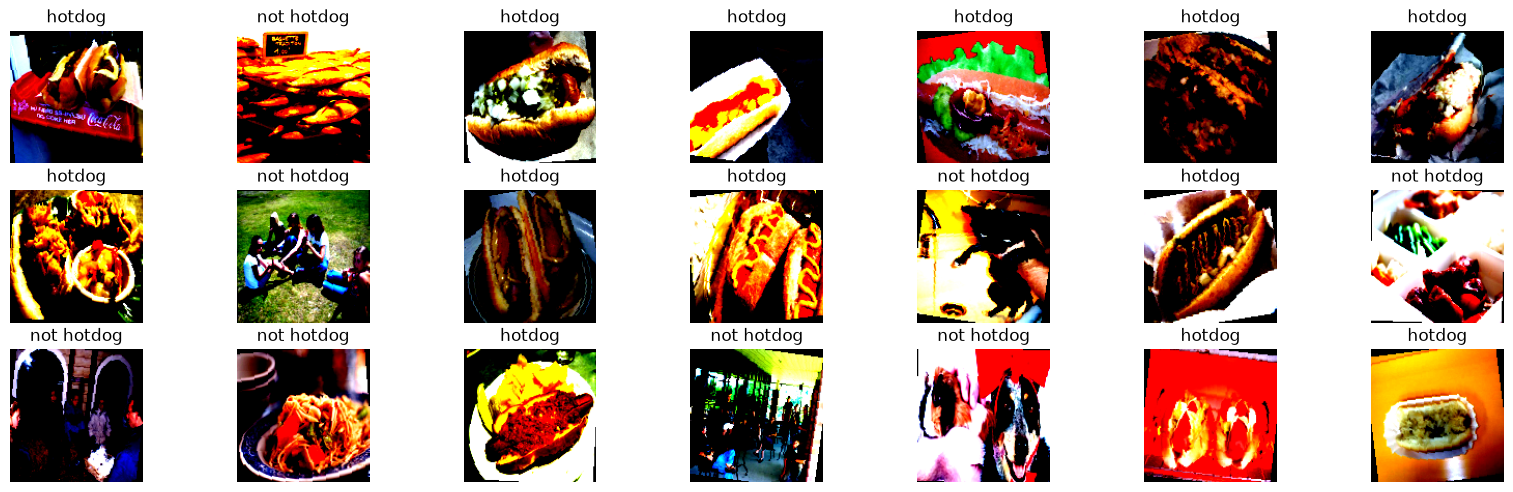

In [138]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(20,10))

for i in range(21):
    plt.subplot(5,7,i+1)
    plt.imshow(np.swapaxes(np.swapaxes(images[i].numpy(), 0, 2), 0, 1))
    plt.title(['hotdog', 'not hotdog'][labels[i].item()])
    plt.axis('off')


Now create a model and train it!


In [141]:
class Network(nn.Module):
    def __init__(self):
        super(Network, self).__init__()

        self.model = models.resnet18(weights="DEFAULT")

        # Freeze pretrained layers
        for param in self.model.parameters():
            param.requires_grad = False

        # Replace ImageNet classifier with our 2-class classifier
        self.model.fc = nn.Linear(
            self.model.fc.in_features,
            2
        )
        
    def forward(self, x):
        return self.model(x)

In [142]:
model = Network()
model.to(device)

optimizer = torch.optim.Adam(
    model.model.fc.parameters(),
    lr=0.001
)

data = next(iter(train_loader))[0].to(device)

# Run the full model
output = model(data)

print("Output shape:", output.shape)

Output shape: torch.Size([64, 2])


In [ ]:
K = 2
num_epochs = 15
N = len(trainset)

all_ind = np.arange(N)
np.random.shuffle(all_ind)

fold_val_accuracies = []

for fold_ind in range(K):

    split_size = N // K

    val_ind = all_ind[
        fold_ind * split_size : (fold_ind + 1) * split_size
    ]

    train_ind = np.setdiff1d(all_ind, val_ind)

    train_fold = torch.utils.data.Subset(
        trainset, train_ind.tolist()
    )

    val_fold = torch.utils.data.Subset(
        trainset, val_ind.tolist()
    )

    train_fold_loader = DataLoader(
        train_fold,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )

    val_fold_loader = DataLoader(
        val_fold,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    # Fresh pretrained model for each fold
    model = Network().to(device)

    # Only train the new final layer
    optimizer = torch.optim.Adam(
        model.model.fc.parameters(),
        lr=0.001
    )

    for epoch in tqdm(range(num_epochs), unit='epoch'):

        # -----------------
        # Training
        # -----------------
        model.train()

        train_correct = 0

        for data, target in train_fold_loader:

            data = data.to(device)
            target = target.to(device)

            optimizer.zero_grad()

            output = model(data)

            loss = F.cross_entropy(output, target)

            loss.backward()
            optimizer.step()

            predicted = output.argmax(1)

            train_correct += (
                target == predicted
            ).sum().item()

        train_acc = train_correct / len(train_ind)

        # -----------------
        # Validation
        # -----------------
        model.eval()

        val_correct = 0

        with torch.no_grad():

            for data, target in val_fold_loader:

                data = data.to(device)
                target = target.to(device)

                output = model(data)

                predicted = output.argmax(1)

                val_correct += (
                    target == predicted
                ).sum().item()

        val_acc = val_correct / len(val_ind)

        print(
            "Accuracy train: {:.1f}%\t val: {:.1f}%".format(
                100 * train_acc,
                100 * val_acc
            )
        )

    fold_val_accuracies.append(val_acc)


ave_acc = np.mean(fold_val_accuracies)

print(
    f"Average validation accuracy over {K} folds: "
    f"{100 * ave_acc:.1f}%"
)

  7%|▋         | 1/15 [00:22<05:21, 22.99s/epoch]

Accuracy train: 69.3%	 val: 82.7%


 13%|█▎        | 2/15 [00:46<04:59, 23.02s/epoch]

Accuracy train: 84.2%	 val: 84.6%


 20%|██        | 3/15 [01:11<04:48, 24.01s/epoch]

...

Accuracy train: 84.9%	 val: 86.1%


 33%|███▎      | 5/15 [01:54<03:48, 22.82s/epoch]

Accuracy train: 86.4%	 val: 88.4%


 40%|████      | 6/15 [02:18<03:28, 23.19s/epoch]

Accuracy train: 87.2%	 val: 85.3%
